In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad
from conics import ezellipse

from ttnte.xs.benchmarks import kaist
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

In [2]:
# Discretization
num_ordinates = 64

# Get XS data
xs_server = kaist()

# TODO: Remove this once we're certain things are running correctly
xs_server._num_moments = 1
for mat in xs_server.materials:
    xs_server._xs[mat]["scatter_gtg"] = xs_server.scatter_gtg(mat)[[0], ...]

In [3]:
D = 1.26 # Fuel width
D2 = D*0.5
X = 1.36 # Channel pitch
delta = 0.306 # Width of lobes
y2 = delta * 0.5
d = 0.04 # Thickness of cladding at valleys
dmax = 0.102 # Thickness of cladding at ends of the lobes
R = 0.297 # Radius defining outer curve of valleys
a = 0.156 # Displacer width


y1 = y2-d # Half of width of inner lobe
x1 = (D2 - R - y2 - dmax) # Portrusion of innerlobe
x2 = x1 + dmax # Portrusion of outer lobe

In [4]:
# Generate shapes for meshing
corner = cad.line(p0=(X/2,X/2), p1=(X/2,X/2))

# Boundaries for upper lobe
boundu = cad.line( p0=(D2-x2, X/2), p1=(0,X/2),)
boundrh = cad.line(p0=(D2-x2,D2-x2), p1=(D2-x2, X/2))

# Boundaries for lower lobe
bounduh = cad.line( p0=(X/2, D2-x2), p1=(D2-x2,D2-x2),)
boundr = cad.line(p0=(X/2,0), p1=(X/2, D2-x2))

# Edges for upper lobe
centeru = np.array([0,D2-x2,0])
lobeui = ezellipse(center=centeru, angle=np.pi / 2, xstretch=y1, ystretch=x1)
lobeuo = ezellipse(center=centeru, angle=np.pi / 2, xstretch=y2, ystretch=x2)

# Edges for lower lobe
centerl = np.array([D2-x2,0,0])
lobeli = ezellipse(center=centerl, angle=np.pi / 2,  xstretch=x1, ystretch=y1)
lobelo = ezellipse(center=centerl, angle=np.pi / 2, xstretch=x2, ystretch=y2)

# Edges for center
centerm = np.array([D2-x2,D2-x2,0])
centero = cad.circle(center=centerm, radius = R, angle=[np.pi, np.pi*3/2] )
centeri = cad.circle(center=centerm, radius = R+d, angle=[np.pi, np.pi*3/2] )
boundl = cad.line(p0 =(y1,D2-x2), p1=(y1,y1))
boundd = cad.line(p0=(y1,y1), p1=(D2-x2,y1))

# Slicing
lobel = cad.line(p0=(D2-x2, 0), p1=(D2-x2, 0))
lobeli1 = lobeli.slice(0, 0, 0.5)
lobeli2 = lobeli.slice(0, 0.5, 1.0)
lobelo1 = lobelo.slice(0, 0, 0.5)
lobelo2 = lobelo.slice(0, 0.5, 1.0)

lobeu = cad.line(p0=(0, D2-x2), p1=(0, D2-x2))
lobeui1 = lobeui.slice(0, 0, 0.5)
lobeui2 = lobeui.slice(0, 0.5, 1.0)
lobeuo1 = lobeuo.slice(0, 0, 0.5)
lobeuo2 = lobeuo.slice(0, 0.5, 1.0)

centere =cad.line(p0=(D2-x2,D2-x2),p1=(D2-x2,D2-x2))
centeri1 = centeri.slice(0, 0, 0.5)
centeri2 = centeri.slice(0, 0.5, 1.0)
centero1 = centero.slice(0, 0, 0.5)
centero2 = centero.slice(0, 0.5, 1.0)

po1=(a/(2**0.5),0)
po0=(0,a/(2**0.5))
burn = cad.line(p1=po1,p0=po0)
burnl = burn.slice(0,0, 0.5)
burnd = burn.slice(0,0.5,1.0)
origin = cad.line(p0=(0,0), p1=(0,0))
burne = cad.line(p1=(y1,y1),p0=(y1,y1))
burnd1 =cad.line(p0=po1, p1=(D2-x2,0))
burnd2 = cad.line(p1=po1,p0=(0,0))
burnl1 =cad.line(p1=po0, p0=(0,D2-x2))
burnl2 = cad.line(p1=po0,p0=(0,0))

In [5]:
# Create fuel lower lobe
fuell1 = cad.ruled(lobel, lobeli1)
fuell2 = cad.ruled(lobel, lobeli2)

# Create cladding lower lobe
cladl1 = cad.ruled(lobeli1, lobelo1)
cladl2 = cad.ruled(lobeli2, lobelo2)

# Create Water Region
waterl1 = cad.ruled(lobelo1, boundr)
waterl2 = cad.ruled(lobelo2, bounduh)

# Create fuel upper lobe
fuelu1 = cad.ruled(lobeu, lobeui1)
fuelu2 = cad.ruled(lobeu, lobeui2)

# Create cladding upper lobe
cladu1 = cad.ruled(lobeui1, lobeuo1)
cladu2 = cad.ruled(lobeui2, lobeuo2)

# Create Water Region
wateru1 = cad.ruled(lobeuo1, boundrh)
wateru2 = cad.ruled(lobeuo2, boundu)

# Create Water Region
waterc1 = cad.ruled(centero1, centere)
waterc2 = cad.ruled(centero2, centere)

# Create cladding center
cladc1 = cad.ruled(centeri1, centero1)
cladc2 = cad.ruled(centeri2, centero2)

# Create fuel center
fuelc1 = cad.ruled(boundl, centeri1)
fuelc2 =cad.ruled(boundd, centeri2)

# Create Water corner
waterI = cad.ruled(boundrh, corner)
waterII =cad.ruled(bounduh, corner)

# Fill in the rest
fuelI = cad.ruled(boundl, burnl1)
fuelII = cad.ruled(burne,burnl)
fuelIII = cad.ruled(burne,burnd)
fuelIV =cad.ruled(boundd,burnd1)

absorbI = cad.ruled(burnl,origin)
absorbII = cad.ruled(burnd, origin)

In [6]:
# NURBS surfaces
patches = {}

# Displacer
patches[absorbI] = "BA (UO2 FA)"
patches[absorbII] = "BA (UO2 FA)"

# Fuel
patches[fuell1] = "UO2 3%"
patches[fuell2] = "UO2 3%"
patches[fuelu1] = "UO2 3%"
patches[fuelu2] = "UO2 3%"
patches[fuelc1] = "UO2 3%"
patches[fuelc2] = "UO2 3%"
patches[fuelI] = "UO2 3%"
patches[fuelII] = "UO2 3%"
patches[fuelIV] = "UO2 3%"
patches[fuelIII] = "UO2 3%"

# Cladding
patches[cladl1] = "Guide Tube"
patches[cladl2] = "Guide Tube"
patches[cladc1] = "Guide Tube"
patches[cladc2] = "Guide Tube"
patches[cladu1] = "Guide Tube"
patches[cladu2] = "Guide Tube"

# Water
patches[waterl1] = "Water"
patches[waterl2] = "Water"
patches[waterc1] = "Water"
patches[waterc2] = "Water"
patches[wateru1] = "Water"
patches[wateru2] = "Water"
patches[waterI] = "Water"
patches[waterII] = "Water"

In [7]:
# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 5, 2)

# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

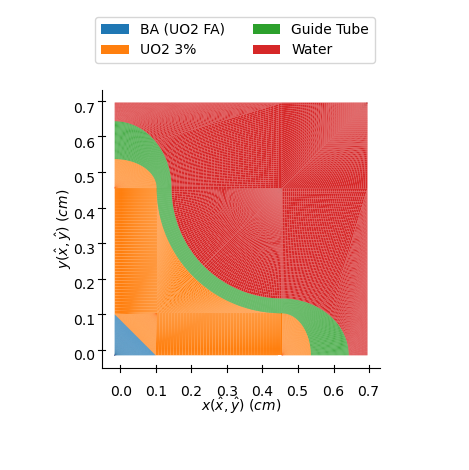

In [8]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False)
plt.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.savefig("./figs/four_lobe.png", dpi=300)
plt.show()

In [9]:
print("Assemble system in COOrdinate format")
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
H_m, S_m, F_m, B_in_m, B_out_m = assembler.build()

# Create operators in TT format
print("\nAssemble system in TT format")
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H_tt, S_tt, F_tt, B_in_tt, B_out_tt = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info.csv")

Assemble system in COOrdinate format
Discretization: N = 64, G = 7, P = 26, A = 7, B = 7
Assembling Patch 1
Step            Shape                     Compression  Elapsed Time (s)
H               570752,570752              288203.74        0.64
S               1,8918,8918                  1313.43        0.64
F               8918,8918                    1501.06        0.65
B_in            570752,570752             5571939.07        0.78
B_out           570752,570752             5624466.41        0.89
Assembling Patch 2
Step            Shape                     Compression  Elapsed Time (s)
H               570752,570752              288203.74        1.51
S               1,8918,8918                  1313.43        1.51
F               8918,8918                    1501.06        1.51
B_in            570752,570752             5571939.07        1.64
B_out           570752,570752             5616320.91        1.75
Assembling Patch 3
Step            Shape                     Compression  Elaps

B_out           570752,570752             4163252.38       19.80
Assembling Patch 21
Step            Shape                     Compression  Elapsed Time (s)
H               570752,570752              288203.74       20.68
S               1,8918,8918                   985.07       20.69
F               8918,8918                        inf       20.69
B_in            570752,570752             5465919.08       20.80
B_out           570752,570752             5520383.76       20.91
Assembling Patch 22
Step            Shape                     Compression  Elapsed Time (s)
H               570752,570752              288203.74       21.82
S               1,8918,8918                   985.07       21.83
F               8918,8918                        inf       21.83
B_in            570752,570752             5425770.67       21.94
B_out           570752,570752             5494962.22       22.05
Assembling Patch 23
Step            Shape                     Compression  Elapsed Time (s)
H        

Intg_int        17                              1.44        4.26
Intg_str        29,2                            1.13        4.26
H               3,3,3,3,3,75                 1854.44        4.26
S               1,1,1,1,1,17              7003436.50        4.26
F               1,1,1,1,1,17              7003436.50        4.26
Jx_det_in       1,3                             1.15        4.39
Jy_det_in       2,3                             0.70        4.39
Rx_in           1,5,3,1                         3.21        4.39
Ry_in           2,8,6,3                         0.93        4.39
Ox_in           4,5,2,1,1                      12.97        4.39
Oy_in           4,5,2,1,1                      12.97        4.39
ORx_in          3,10,15,15,9,3,1                8.86        4.41
ORy_in          4,5,2,2,9,6,3                  37.65        4.41
ORJx_det_in     3,10,15,15,9,3,1                8.86        4.42
ORJy_det_in     4,5,2,4,18,6,3                 19.22        4.42
Intg_bound_in   3,7,9,8,3

Intg_bound_in   3,7,10,12,3                 82523.82       10.12
H_bound_in      5,10,12,12,12,3            190152.94       10.14
B_in            5,10,12,12,12,3           2985563.74       10.14
Jx_det_out      1,3                             1.15       10.15
Jy_det_out      2,3                             0.70       10.15
Rx_out          2,8,6,2                         1.00       10.17
Ry_out          2,8,6,3                         0.93       10.17
Ox_out          4,5,2,1,1                      12.97       10.26
Oy_out          4,5,2,1,1                      12.97       10.26
ORx_out         3,11,15,30,18,6,2               3.62       10.28
ORy_out         4,5,2,2,9,6,3                  37.65       10.28
ORJx_det_out    3,11,15,30,18,6,2               3.62       10.30
ORJy_det_out    4,5,2,4,18,6,3                 19.22       10.30
Intg_bound_out  4,10,12,3                      59.86       10.54
H_bound_out     4,10,12,12,12,3              3821.13       10.55
B_out           4,10,12,1

Intg_bound_out  4,5,4,3                       168.68       15.63
H_bound_out     4,5,4,4,4,3                 19434.92       15.63
B_out           4,5,4,4,4,3                 19434.92       15.63
Assembling Patch 10
Step            Ranks                     Compression  Elapsed Time (s)
J               2,7,3,3,3,3                    34.32       15.87
J_det           1,2,1                           9.38       16.11
R               3,9,9,9,3                       2.79       16.19
dR              3,8,12,12,5,2                   3.79       16.19
J_detRT         3,12,9,9,3                      2.38       16.19
JdR             4,20,18,14,6,2                  1.59       16.20
Intg_int        1                              24.50       16.47
Intg_str        3,2                            10.79       16.47
H               3,3,3,3,3,7                 15953.71       16.47
S               1,1,1,1,1,1               56692976.94       16.47
F               1,1,1,1,1,1               56692976.94       16

Intg_bound_in   4,10,12,17,3                57028.20       21.65
H_bound_in      5,10,13,13,17,3            126362.25       21.67
B_in            5,10,13,13,17,3           1995050.59       21.67
Jx_det_out      2,3                             0.70       21.68
Jy_det_out      1,1                             3.00       21.68
Rx_out          2,10,6,2                        0.83       21.70
Ry_out          2,6,6,3                         1.15       21.70
Ox_out          4,5,2,1,1                      12.97       21.79
Oy_out          4,5,2,1,1                      12.97       21.79
ORx_out         4,16,29,30,18,6,2               2.49       21.81
ORy_out         4,5,2,2,6,6,3                  46.08       21.81
ORJx_det_out    4,16,29,30,18,6,2               2.49       21.83
ORJy_det_out    4,5,2,2,6,6,3                  46.08       21.83
Intg_bound_out  4,10,13,3                      55.80       22.11
H_bound_out     4,10,13,13,13,3              3356.96       22.12
B_out           4,10,13,1

Intg_bound_out  4,10,16,3                      46.35       28.08
H_bound_out     4,10,16,16,16,3              2377.53       28.09
B_out           4,10,16,16,16,3              2377.53       28.09
Assembling Patch 17
Step            Ranks                     Compression  Elapsed Time (s)
J               5,24,12,4,4,4                   4.64       28.33
J_det           5,6,3                           0.95       28.56
R               5,15,15,9,3                     1.29       28.64
dR              5,15,25,12,5,2                  1.53       28.64
J_detRT         5,20,27,9,3                     0.68       28.65
JdR             5,25,48,16,6,2                  0.59       28.67
Intg_int        2                              12.25       29.02
Intg_str        4,2                             8.11       29.02
H               3,3,3,3,3,10                11946.54       29.02
S               1,1,1,1,1,2               39276325.72       29.02
F               1,1,1,1,1,1               56692976.94       29

Intg_bound_in   4,8,10,14,4                 59054.50       35.26
H_bound_in      4,9,14,14,14,4             139688.41       35.28
B_in            4,9,14,14,14,4            2205596.94       35.28
Jx_det_out      2,3                             0.70       35.29
Jy_det_out      2,3                             0.70       35.29
Rx_out          2,8,6,2                         1.00       35.31
Ry_out          2,8,6,3                         0.93       35.31
Ox_out          4,5,2,1,1                      12.97       35.41
Oy_out          4,5,2,1,1                      12.97       35.41
ORx_out         4,12,16,30,18,6,2               3.45       35.42
ORy_out         4,5,2,2,9,6,3                  37.65       35.42
ORJx_det_out    4,12,16,30,18,6,2               3.45       35.44
ORJy_det_out    4,5,2,4,18,6,3                 19.22       35.44
Intg_bound_out  4,9,14,4                       42.64       35.69
H_bound_out     4,9,14,14,14,4               2776.69       35.69
B_out           4,9,14,14

Intg_bound_out  4,9,10,4                       57.42       41.06
H_bound_out     4,9,10,10,10,4               4679.86       41.07
B_out           4,9,10,10,10,4               4679.86       41.07
Assembling Patch 24
Step            Ranks                     Compression  Elapsed Time (s)
J               5,25,12,4,4,4                   4.49       41.31
J_det           5,9,3                           0.66       41.55
R               5,25,25,9,3                     0.62       41.63
dR              5,25,48,16,6,2                  0.59       41.63
J_detRT         5,25,27,9,3                     0.58       41.64
JdR             5,25,48,16,6,2                  0.59       41.66
Intg_int        18                              1.36       42.07
Intg_str        29,2                            1.13       42.07
H               3,3,3,3,3,76                 1830.65       42.07
S               1,1,1,1,1,18              6639718.02       42.07
F               1,1,1,1,1,1               56692976.94       42.

In [10]:
k, psi = eig(
    LHS=LinearOperator([H_tt, B_out_m - B_in_m, -S_tt], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F_tt], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=1,
    linear_solver_opts={
        "max_iterations": 200,
        "threshold": 1e-10,
        "resets": 50,
    },
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 0.64482772, Angular Flux L2-Error = 2.68649978, Elapsed Time = 222.463
-- (1): k = 0.70316393, Angular Flux L2-Error = 0.03613632, Elapsed Time = 444.99
-- (2): k = 0.70245423, Angular Flux L2-Error = 0.00139253, Elapsed Time = 667.329


KeyboardInterrupt: 

In [ ]:
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False, num_nodes=128)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}.png", dpi=300)
    plt.show()